## El cuadro maestro: año por región

**Fase 3 · limpieza y cruzamiento (guía).** Con las fuentes ya depuradas, en este cuaderno se arma el cuadro maestro **año × región**: el corazón del cruce entre precios, salario joven y anomalías climáticas.

In [1]:
import sys
from pathlib import Path
_ROOT = Path.cwd()
while not any((_ROOT / c).exists() for c in ['db', 'data']) and _ROOT != _ROOT.parent:
    _ROOT = _ROOT.parent
sys.path.insert(0, str(_ROOT / 'script'))
from proyecto import graficos
display(graficos.fig_fases())

<Figure size 1344x364 with 1 Axes>

## 1. Buscar la raíz del proyecto

In [2]:
%matplotlib inline
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

PROYECTO = Path.cwd()
while not any((PROYECTO / c).exists() for c in ['db', 'data']) and PROYECTO != PROYECTO.parent:
    PROYECTO = PROYECTO.parent

sys.path.insert(0, str(PROYECTO / 'script'))
from proyecto import config
from proyecto import (cargar, limpiar, diagnostico, transformaciones, cruces,
                      indicadores, validacion, graficos)

def presentar(fig):
    display(fig)

print('raiz del proyecto:', PROYECTO.name)
print('fuentes en data/crudo:', [p.name for p in config.DATA_CRUDO.glob('*.csv')])

raiz del proyecto: mineria
fuentes en data/crudo: ['Average_UK_houseprices_and_salary.csv', 'Income_by_age_and_gender.csv', 'MET_Office_Weather_Data.csv', 'UK_Mortgage_Rate.csv']


## 2. Agregar las ventas por región y por ciudad

In [3]:
t = cargar.cargar_precios_limpios()
precios_region = transformaciones.agregado_precios_region(t)
precios_ciudad = transformaciones.agregado_precios_ciudad(t)
print('por region:', precios_region.shape, '| por ciudad:', precios_ciudad.shape)
display(precios_region.head(8))

por region: (120, 5) | por ciudad: (14050, 6)


,anio,region,n_transacciones,precio_medio,precio_mediana
0,2015,East Midlands,86170,186686.175560,157500.0
1,2015,East of England,117960,273149.272542,235000.0
2,2015,London,128977,434655.337990,397500.0
3,2015,North East,41222,150743.336713,127000.0
4,2015,North West,118423,169296.845951,140000.0
5,2015,South East,174701,312106.142443,270000.0
6,2015,South West,114037,248196.655410,215000.0
7,2015,Wales,48161,165482.861693,142000.0


## 3. El salario joven (18-34)

La fuente F4b publica la mediana por banda y género. El joven se define hasta los 34, así que se promedian las bandas 18-21 (GBP 18.392), 22-29 (26.856) y 30-39 (34.210); la franja 30-39 cubre de sobra los 30-34. Ese promedio es el factor que se aplica a cada año de la serie nacional.

In [4]:
ingreso = cargar.cargar_ingreso_edad()
precios = cargar.cargar_precios_salario()
joven, factor = transformaciones.salario_joven(ingreso, precios)
print(f'salario joven 18-34 = GBP {joven:,.0f}')
print(f'factor joven vs mediana nacional 2020 = {factor:.3f}')
serie_salario = transformaciones.serie_salario_joven(precios, factor)
display(serie_salario.sample(8, random_state=config.SEED))
print('factor regional (referencia ASHE 2021):', config.FACTOR_REGIONAL)

salario joven 18-34 = GBP 25,353
factor joven vs mediana nacional 2020 = 0.805


,anio,salario_mediana_real,salario_joven_nacional,region,factor_regional,salario_joven_region
132,1999,31551.55,25404.974979,North West,0.91,23118.527230
148,2015,31307.83,25208.734207,North West,0.91,22939.948129
93,2004,34630.76,27884.322364,East Midlands,0.92,25653.576575
180,2003,34155.19,27501.398421,North East,0.85,23376.188658
15,2014,31159.83,25089.566170,London,1.25,31361.957712
115,2004,34630.76,27884.322364,West Midlands,0.91,25374.733351
172,2017,30939.54,24912.190987,Yorkshire and The Humber,0.88,21922.728069
209,2010,33938.03,27326.543481,Wales,0.90,24593.889133


factor regional (referencia ASHE 2021): {'London': 1.25, 'South East': 1.06, 'East of England': 1.01, 'South West': 0.95, 'East Midlands': 0.92, 'West Midlands': 0.91, 'North West': 0.91, 'Yorkshire and The Humber': 0.88, 'North East': 0.85, 'Wales': 0.9}


## 4. Armar el cruce maestro_joven_uk

Para cada **año y región** se juntan el precio mediano, el salario joven regionalizado y las anomalías climáticas. El resultado: 6 años por 10 regiones.

In [5]:
anual = transformaciones.clima_anual(limpiar.limpiar_clima(cargar.cargar_clima())[0])
anom_nac, anom_reg = transformaciones.anomalias_climaticas(anual)
maestro = cruces.cruce_maestro(precios_region, serie_salario, anom_reg)
display(maestro)
print('filas:', len(maestro), '| nulos:', int(maestro.isna().sum().sum()))

,anio,region,n_transacciones,precio_medio,precio_mediana,salario_mediana_real,salario_joven_nacional,factor_regional,salario_joven_region,tmax_anom,tmin_anom,lluvia_anom,sol_anom,af_anom,precio_var_pct,anos_salario
0,2015,East Midlands,86170,186686.175560,157500.0,31307.83,25208.734207,0.92,23192.035471,1.000338,0.742342,-6.180180,3.150000,-18.459459,NaN,6.791124
1,2016,East Midlands,92306,196291.419929,165000.0,31420.16,25299.181138,0.92,23275.246647,0.725338,0.767342,3.936486,-3.791667,-12.459459,4.761905,7.089076
2,2017,East Midlands,92767,210646.584993,178000.0,30939.54,24912.190987,0.92,22919.215708,0.942005,1.259009,-1.830180,-9.383333,-14.459459,7.878788,7.766409
3,2018,East Midlands,91765,219741.545491,185500.0,30772.44,24777.643831,0.92,22795.432325,1.267005,0.959009,-0.996847,6.475000,-8.459459,4.213483,8.137595
4,2019,East Midlands,89086,222895.286555,190000.0,30833.95,24827.171034,0.92,22840.997351,1.083671,0.850676,16.253153,4.533333,-21.459459,2.425876,8.318376
5,2020,East Midlands,78078,236787.872807,202500.0,31487.00,25353.000000,0.92,23324.760000,0.650338,-0.299324,-11.946847,36.691667,-34.459459,6.578947,8.681761
6,2015,East of England,117960,273149.272542,235000.0,31307.83,25208.734207,1.01,25460.821550,0.885883,0.661608,-5.391098,NaN,-17.955113,NaN,9.229867
7,2016,East of England,119175,292851.133996,255000.0,31420.16,25299.181138,1.01,25552.172949,0.677550,0.428275,-4.332765,NaN,-12.455113,8.510638,9.979582
8,2017,East of England,117041,312592.530814,275000.0,30939.54,24912.190987,1.01,25161.312897,0.685883,0.894941,4.550568,NaN,-15.955113,7.843137,10.929477
9,2018,East of England,112201,318128.037923,280000.0,30772.44,24777.643831,1.01,25025.420270,1.085883,0.594941,-4.399432,NaN,-15.455113,1.818182,11.188623


filas: 60 | nulos: 28


## 5. Las ciudades más caras... y las más baratas

In [6]:
top = cruces.cruce_ciudades_tope(precios_ciudad, config.VENTANA_CUADRO)
display(top.head(10))
baratas = (precios_ciudad[(precios_ciudad['anio'] == 2020) & (precios_ciudad['n_transacciones'] > 50)]
          .sort_values('precio_mediana').head(10))
display(baratas[['region', 'ciudad', 'precio_mediana']])

,anio,region,ciudad,n_transacciones,precio_medio,precio_mediana
0,2016,South West,ELY,1,725500.000000,725500.0
1,2019,West Midlands,CROWBOROUGH,1,725500.000000,725500.0
2,2018,London,KESTON,55,646078.945455,725500.0
3,2016,South East,GERRARDS CROSS,374,626177.807487,725500.0
4,2016,South East,HOUNSLOW,3,725500.000000,725500.0
5,2016,South East,ESHER,338,595832.946746,725500.0
6,2016,South East,VIRGINIA WATER,83,609734.939759,725500.0
7,2015,South East,HOUNSLOW,1,725500.000000,725500.0
8,2016,East of England,MUCH HADHAM,29,580430.862069,725500.0
9,2015,South West,BAMPTON,1,725500.000000,725500.0


,region,ciudad,precio_mediana
6161,North East,FERRYHILL,48000.0
6186,North East,SHILDON,52250.0
6779,Wales,FERNDALE,62000.0
6177,North East,PETERLEE,63000.0
6844,Wales,NEW TREDEGAR,67000.0
6193,North East,TRIMDON STATION,68800.0
6883,Wales,TREORCHY,74000.0
6725,Wales,ABERTILLERY,75000.0
6840,Wales,MOUNTAIN ASH,75000.0
6189,North East,STANLEY,78500.0


## 6. Ver los resultados en figuras

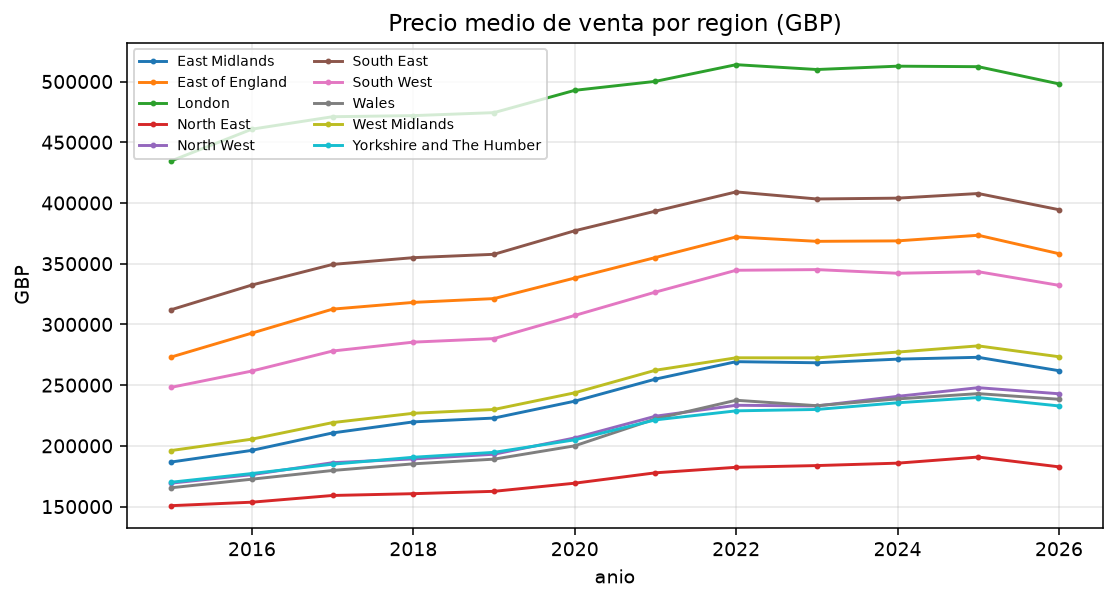

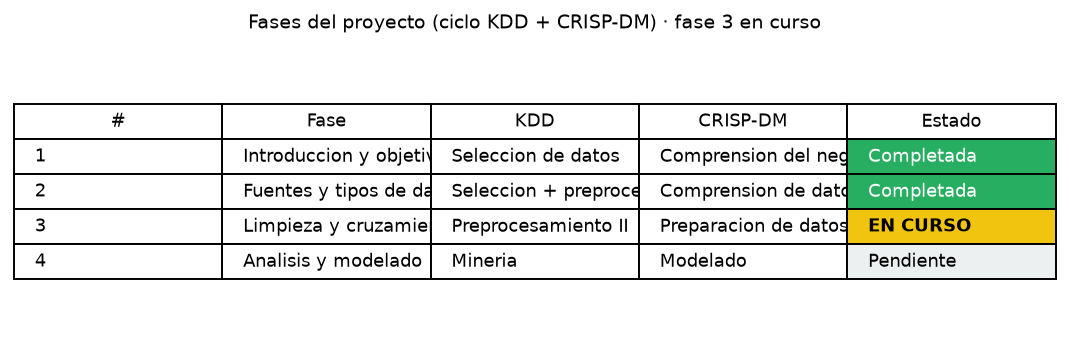

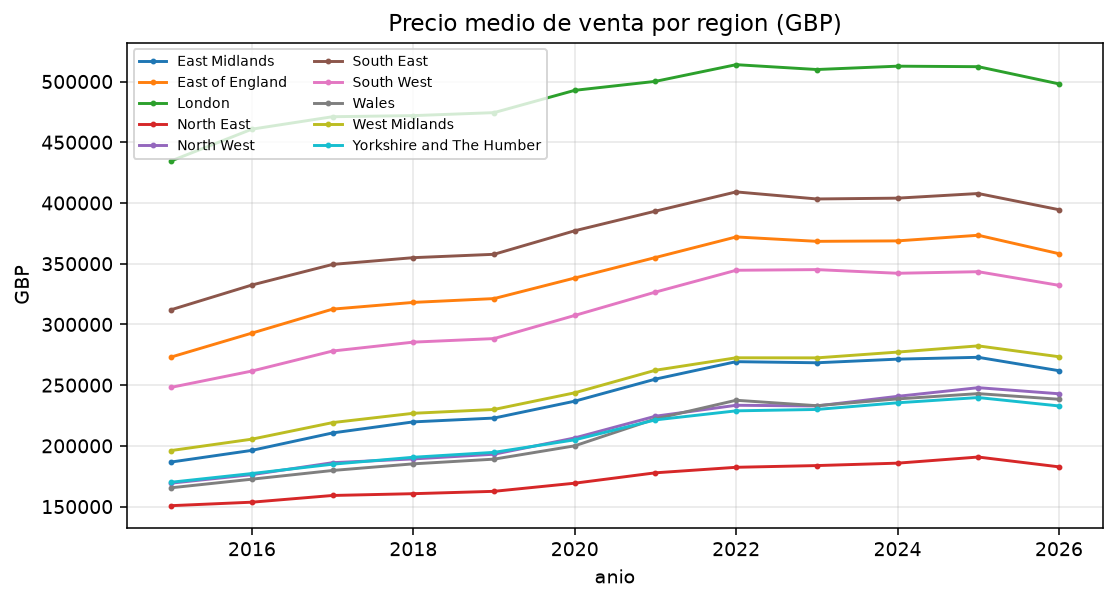

In [7]:
presentar(graficos.fig_precios_region(precios_region))

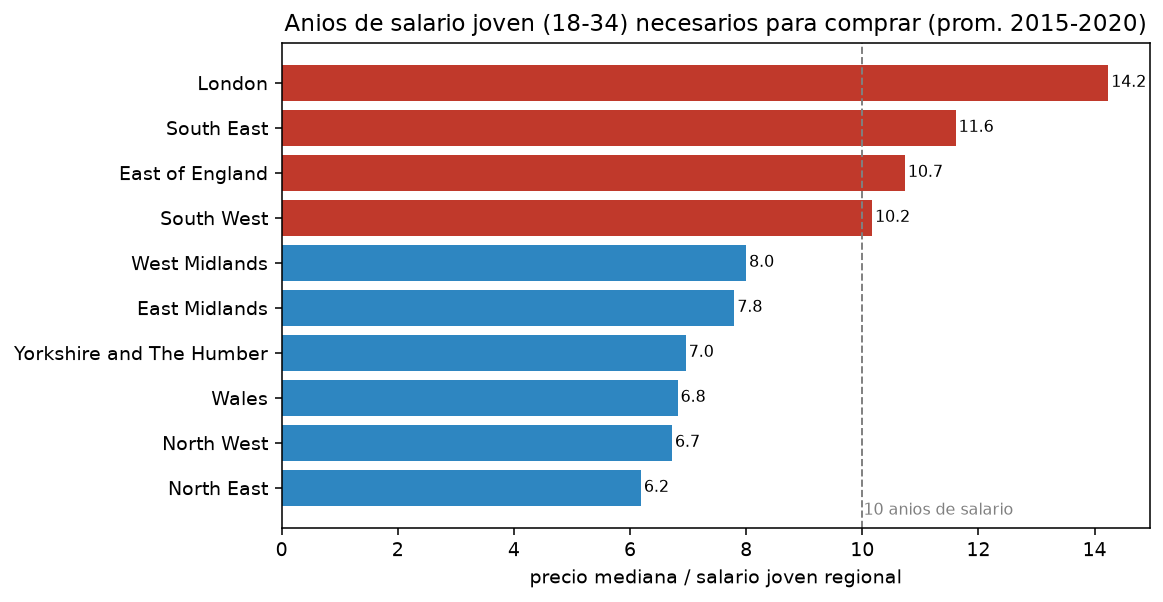

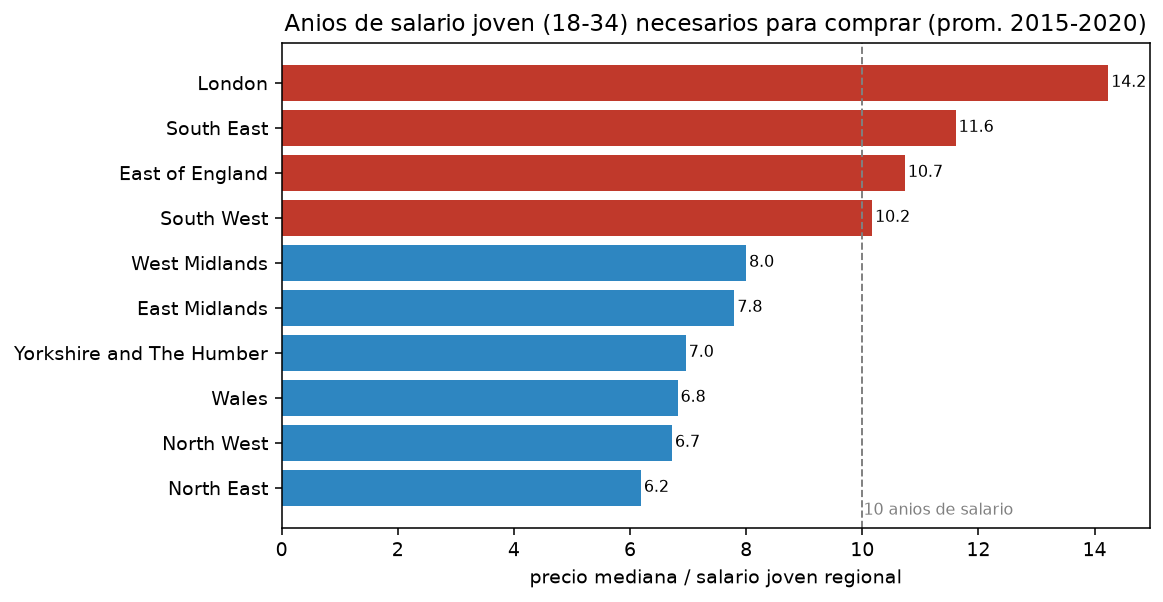

In [8]:
presentar(graficos.fig_anos_salario(maestro))

## A modo de lectura

La brecha es enorme: **London se acerca a los 14 años** de salario joven para comprar la vivienda mediana, mientras el **North East** se queda cerca de 6. Ninguna región baja de la regla prudente de 4 años que suele usarse como techo sano.

## Cierre del cuaderno

El cuadro `maestro_joven_uk` queda con 60 filas (6 años × 10 regiones), sin huecos en precio ni salario y con las anomalías climáticas listas. Lo retomaremos en el cuaderno 05.